# KYC Funnel Drop-off Analysis
Data is **SIMULATED** (real KYC data is private). The generator deliberately gives
Budget-Android devices higher failure rates on camera steps, so the device-tier finding is a real, discoverable
pattern in the data, not a claim invented after the fact.

**Framework:** Step-Metrics Matrix = Volume Velocity (conversion / drop-off %) + Friction Density (retries / errors)
+ Time Dwell (median duration / time-to-abandon).

**Sections:** 1) Load  2) Clean  3) Step-Metrics Matrix  4) Time-to-Abandon  5) Error-Impact Mapping  6) Device Tier cohorts  7) Vendor waste  8) Recommendations

## 1. Setup and load from MySQL

In [1]:
# Load the required libraries, database helpers, and KYC session/event data.

import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "scripts")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from db_connector import get_engine, load_sessions, load_events

sns.set_theme(style="whitegrid")
STEPS = ["registration", "phone_otp", "doc_upload", "liveness_check", "consent_sign"]
os.makedirs(os.path.join("..", "outputs"), exist_ok=True)

engine = get_engine()
sessions = load_sessions(engine)
events = load_events(engine)
print("sessions:", sessions.shape, "| events:", events.shape)


sessions: (10000, 13) | events: (48755, 10)


## 2. Cleaning and validation
The data is generated, so we expect it to be clean. We still **check instead of assuming**.

In [2]:
# Validate the loaded data, standardize types, and create the error flag used in analysis.

print("Missing values in sessions:\n", sessions.isna().sum()[sessions.isna().sum() > 0])
print("Missing values in events (error_type NULL = successful attempt, expected):")
print(events.isna().sum()[events.isna().sum() > 0])
print("Duplicate session_ids:", sessions.session_id.duplicated().sum())
print("Orphan events:", (~events.session_id.isin(sessions.session_id)).sum())
events["event_time"] = pd.to_datetime(events["event_time"])
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
events["stage"] = pd.Categorical(events["stage"], categories=STEPS, ordered=True)
events["is_error"] = events["error_type"].notna().astype(int)
print("\nOverall abandonment rate:", round(sessions.has_abandoned.mean() * 100, 2), "%")


Missing values in sessions:
 Series([], dtype: int64)
Missing values in events (error_type NULL = successful attempt, expected):
error_type    43412
dtype: int64
Duplicate session_ids: 0
Orphan events: 0

Overall abandonment rate: 26.35 %


## 3. Step-Metrics Matrix (Volume Velocity, Friction Density, Time Dwell)

In [3]:
# Calculate funnel volume, drop-off, conversion, friction, and time metrics for each stage.

reached = events.groupby("stage", observed=True).session_id.nunique()
dropped = events[events.drop_off_flag == 1].groupby("stage", observed=True).session_id.nunique()
dropped = dropped.reindex(STEPS).fillna(0)

matrix = pd.DataFrame({"sessions_reached": reached.reindex(STEPS), "sessions_dropped": dropped})
matrix["dropoff_pct"] = (matrix.sessions_dropped / matrix.sessions_reached * 100).round(2)
matrix["conversion_pct"] = (100 - matrix.dropoff_pct).round(2)
matrix["cumulative_pct_of_all"] = (matrix.sessions_reached / matrix.sessions_reached.iloc[0] * 100).round(2)

g = events.groupby("stage", observed=True)
matrix["avg_retries"] = g.retry_count.mean().reindex(STEPS).round(3)
matrix["errors_per_session"] = (g.is_error.sum() / reached).reindex(STEPS).round(3)
matrix["median_seconds"] = g.time_on_step.median().reindex(STEPS)
matrix.to_csv(os.path.join("..", "outputs", "step_metrics_matrix.csv"))
matrix

,sessions_reached,sessions_dropped,dropoff_pct,conversion_pct,cumulative_pct_of_all,avg_retries,errors_per_session,median_seconds
stage,,,,,,,,
registration,10000,549,5.49,94.51,100.00,0.033,0.036,24.0
phone_otp,9451,353,3.74,96.26,94.51,0.055,0.063,19.0
doc_upload,9098,675,7.42,92.58,90.98,0.161,0.216,44.0
liveness_check,8423,715,8.49,91.51,84.23,0.168,0.245,30.0
consent_sign,7708,343,4.45,95.55,77.08,0.041,0.046,14.0


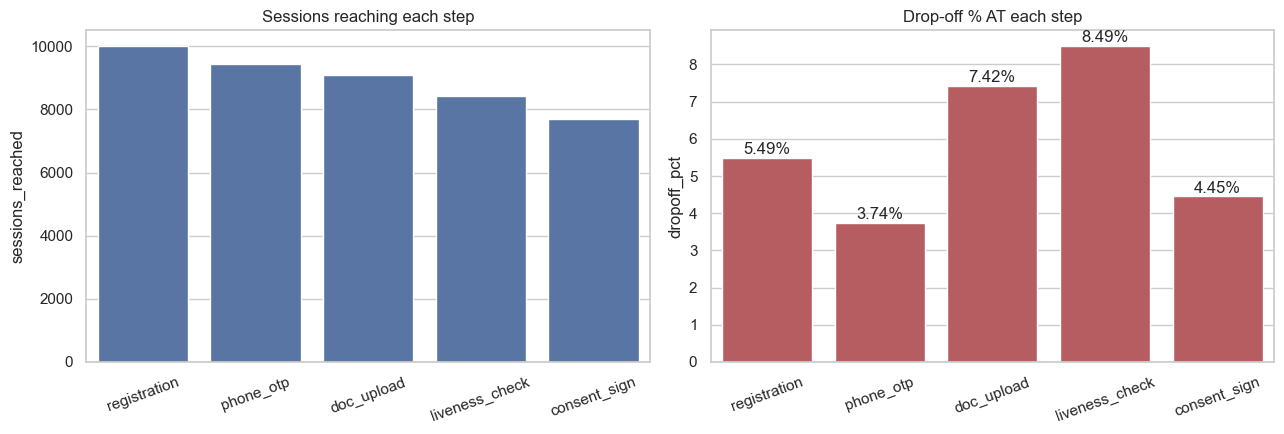

In [4]:
# Visualize sessions reaching each stage and the drop-off rate at each stage.

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=matrix.index, y=matrix.sessions_reached, ax=ax[0], color="#4C72B0")
ax[0].set_title("Sessions reaching each step"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=20)
sns.barplot(x=matrix.index, y=matrix.dropoff_pct, ax=ax[1], color="#C44E52")
ax[1].set_title("Drop-off % AT each step"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(matrix.dropoff_pct): ax[1].text(i, v + 0.1, f"{v}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join("..", "outputs", "01_funnel_dropoff.png"), dpi=130); plt.show()


**Reading the matrix:** the biggest leak is `liveness_check`, followed by `doc_upload`. These two camera-based steps also have
the highest Friction Density (errors per session). Registration loses users too, but with almost no errors, which points to
*intent*, not a technical fault. The next section tests exactly that.

## 4. Time-to-Abandon: no-intent quitters vs technical-blocker quitters
A session's total time on the step where it quit separates users who never tried (<5 s) from those who struggled (>60 s).

In [5]:
# Classify abandoned sessions by time spent on the step where they quit.

step_time = events.groupby(["session_id", "stage"], observed=True).time_on_step.sum().reset_index(name="step_seconds")
quit_pts = events[events.drop_off_flag == 1][["session_id", "stage"]].drop_duplicates()
tta = quit_pts.merge(step_time, on=["session_id", "stage"])
tta["cohort"] = pd.cut(tta.step_seconds, bins=[-1, 4, 60, 10**6],
                       labels=["No-intent (<5s)", "Mid (5-60s)", "Blocker (60s+)"])
tta["stage"] = pd.Categorical(tta["stage"], categories=STEPS, ordered=True)
tta_tab = tta.groupby(["stage", "cohort"], observed=True).size().unstack(fill_value=0)
tta_tab["blocker_share_%"] = (tta_tab["Blocker (60s+)"] / tta_tab.sum(axis=1) * 100).round(1)
tta_tab.to_csv(os.path.join("..", "outputs", "time_to_abandon.csv"))
tta_tab

cohort,No-intent (<5s),Mid (5-60s),Blocker (60s+),blocker_share_%
stage,,,,
registration,516,32,1,0.2
phone_otp,274,78,1,0.3
doc_upload,209,306,160,23.7
liveness_check,89,512,114,15.9
consent_sign,300,43,0,0.0


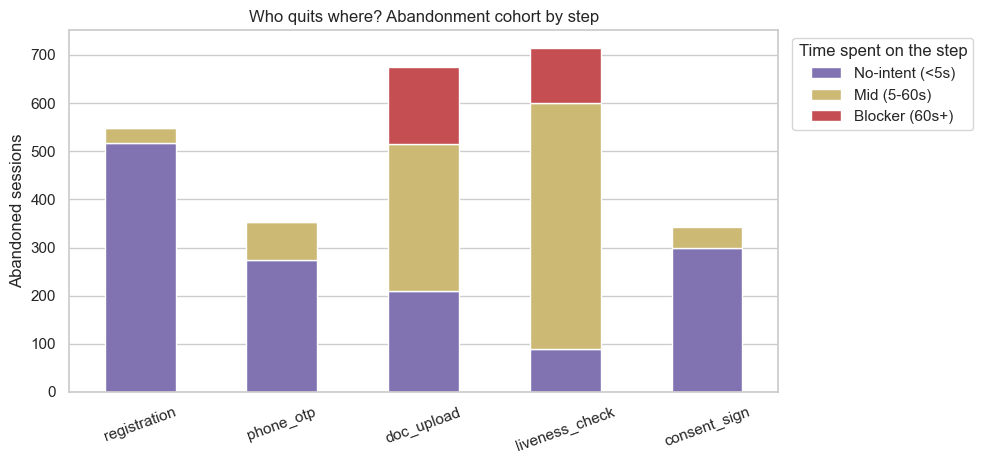

In [6]:
# Visualize abandonment cohorts by funnel stage.

plot_df = tta_tab[["No-intent (<5s)", "Mid (5-60s)", "Blocker (60s+)"]]
plot_df.plot(kind="bar", stacked=True, figsize=(10, 4.8), color=["#8172B2", "#CCB974", "#C44E52"])
plt.title("Who quits where? Abandonment cohort by step"); plt.xlabel(""); plt.ylabel("Abandoned sessions")
plt.grid(axis="x", visible=False)
plt.legend(title="Time spent on the step", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "02_time_to_abandon.png"), dpi=130); plt.show()


**Signature insight:** early steps lose users almost entirely in **under 5 seconds** (registration 94% of its quits, OTP 78%, consent 87%) --
that is *no intent*, a product/copy/trust problem, not a technical one. The camera steps are different: **24% of `doc_upload` quitters
and 16% of `liveness_check` quitters spent over a minute trying** (the signature of a technical blocker), and most of the rest tried for 5-60 s.
Two different problems, two different owning teams.

## 5. Error-Impact Mapping
Does seeing a specific error code make a user more likely to abandon?

In [7]:
# Measure abandonment associated with each error type against the overall baseline.

err = events[events.is_error == 1][["session_id", "error_type"]].drop_duplicates()
err = err.merge(sessions[["session_id", "has_abandoned"]], on="session_id")
impact = err.groupby("error_type").agg(sessions=("session_id", "nunique"),
                                       abandonment_pct=("has_abandoned", lambda x: round(x.mean() * 100, 2))).sort_values("abandonment_pct", ascending=False)
baseline = round(sessions.has_abandoned.mean() * 100, 2)
clean_sessions = sessions[~sessions.session_id.isin(err.session_id)]
print("Baseline abandonment (all users):", baseline, "%")
print("Abandonment among sessions with ZERO errors:", round(clean_sessions.has_abandoned.mean() * 100, 2), "%")
impact.to_csv(os.path.join("..", "outputs", "error_impact.csv"))
impact

Baseline abandonment (all users): 26.35 %
Abandonment among sessions with ZERO errors: 20.34 %


,sessions,abandonment_pct
error_type,,
ERR_GLARE_DETECTED,623,42.22
ERR_FACE_NOT_FOUND,909,41.69
ERR_BLURRY_DOC,597,40.37
ERR_TIMEOUT,2539,35.05


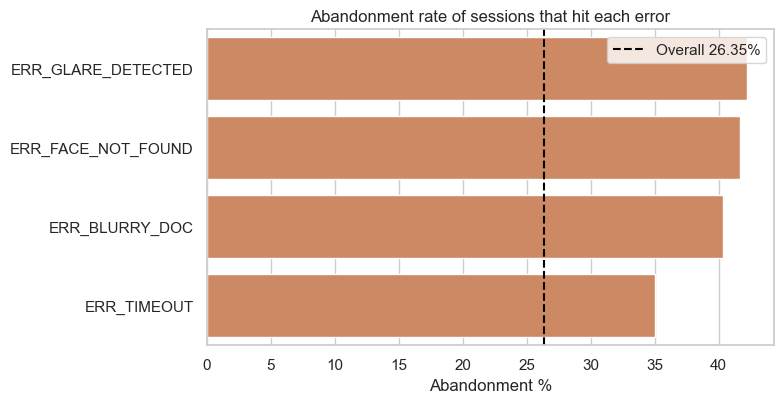

In [8]:
# Visualize abandonment rates for sessions encountering each error type.

plt.figure(figsize=(8, 4.2))
sns.barplot(x=impact.abandonment_pct, y=impact.index, color="#DD8452")
plt.axvline(baseline, color="black", ls="--", label=f"Overall {baseline}%")
plt.legend(); plt.title("Abandonment rate of sessions that hit each error"); plt.xlabel("Abandonment %"); plt.ylabel("")
plt.tight_layout(); plt.savefig(os.path.join("..", "outputs", "03_error_impact.png"), dpi=130); plt.show()


**Honest reading:** sessions that hit any error abandon at **35-42%**, versus **20.3%** for sessions with no errors (baseline 26.4%) -- roughly **1.7-2x**.
Note the zero-error group still abandons at 20% because "no-intent" quitters leave before any error can occur. The four codes differ only modestly
(glare/face-not-found/blur ~40-42%, timeout 35%); `ERR_TIMEOUT` occurs on every step, which dilutes it. The defensible finding is *"errors hurt"*,
not *"one error is the villain"*. Errors here are simulated with the same frustration rule, so we do not claim a ranking among them.

## 6. Device Tier cohort analysis

In [9]:
# Compare abandonment and friction metrics across device tiers.

dev = sessions.groupby("device_tier").agg(sessions=("session_id", "count"),
                                           abandonment_pct=("has_abandoned", lambda x: round(x.mean() * 100, 2)),
                                           avg_doc_retries=("document_upload_retries", "mean"),
                                           avg_bio_errors=("biometric_error_count", "mean")).round(2).sort_values("abandonment_pct", ascending=False)
dev.to_csv(os.path.join("..", "outputs", "device_tier_summary.csv"))
dev

,sessions,abandonment_pct,avg_doc_retries,avg_bio_errors
device_tier,,,,
Android-Budget,1937,40.11,0.43,0.43
Android-MidTier,4010,26.56,0.18,0.20
iOS-HighEnd,4053,19.57,0.10,0.10


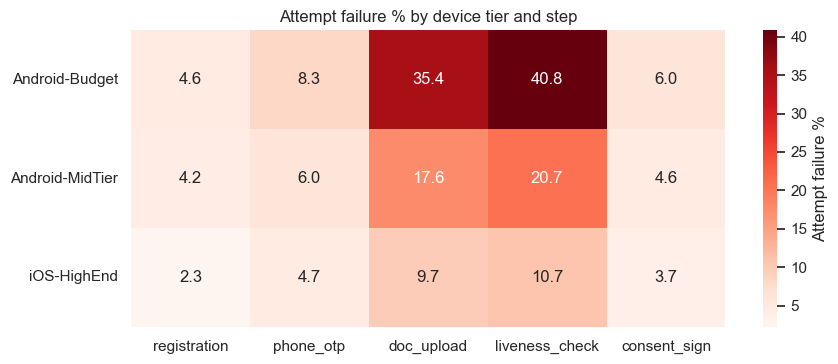

In [10]:
# Compare attempt failure rates across device tiers and funnel stages.

fail = (events.groupby(["device_type", "stage"], observed=True).is_error.mean() * 100).unstack().reindex(columns=STEPS).round(1)
plt.figure(figsize=(9, 3.8))
sns.heatmap(fail, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Attempt failure %"})
plt.title("Attempt failure % by device tier and step"); plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.savefig(os.path.join("..", "outputs", "04_device_step_heatmap.png"), dpi=130); plt.show()


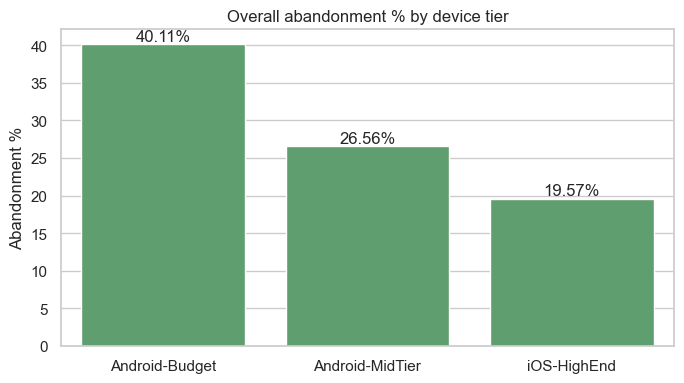

In [11]:
# Visualize overall abandonment by device tier.

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=dev.index, y=dev.abandonment_pct, ax=ax, color="#55A868")
for i, v in enumerate(dev.abandonment_pct): ax.text(i, v + 0.5, f"{v}%", ha="center")
ax.set_title("Overall abandonment % by device tier"); ax.set_xlabel(""); ax.set_ylabel("Abandonment %")
plt.tight_layout(); plt.savefig(os.path.join("..", "outputs", "05_device_abandonment.png"), dpi=130); plt.show()


**Finding:** Budget-Android users fail camera steps far more often than iOS users, and abandon at roughly twice the rate.
Registration, OTP and consent are near-flat across tiers, so the gap is specific to **camera-heavy steps**. That points to an
**engineering / capture-quality fix** (auto-capture, lighter liveness), not a copy or UX-wording fix.

*Caveat:* this gradient was built into the simulator. With real data, the same code would test whether the pattern actually exists.

## 7. Vendor cost bleed (Pain Point 2)

In [12]:
# Calculate total vendor fees and the share wasted on failed verification attempts.

paid = events[events.attempt_cost > 0].copy()
paid["failed_fee"] = np.where(paid.is_error == 1, paid.attempt_cost, 0.0)
waste = paid.groupby("device_type").agg(total_fees=("attempt_cost", "sum"),
                                        wasted_on_failures=("failed_fee", "sum"))
waste["waste_pct"] = (waste.wasted_on_failures / waste.total_fees * 100).round(1)
waste = waste.round(2).sort_values("waste_pct", ascending=False)
waste.to_csv(os.path.join("..", "outputs", "vendor_waste.csv"))
print("Total vendor fees: $", round(paid.attempt_cost.sum(), 2), "| Wasted on failed attempts: $", round(paid.failed_fee.sum(), 2))
waste

Total vendor fees: $ 35101.5 | Wasted on failed attempts: $ 7080.5


,total_fees,wasted_on_failures,waste_pct
device_type,,,
Android-Budget,7540.5,2924.0,38.8
Android-MidTier,14043.0,2750.0,19.6
iOS-HighEnd,13518.0,1406.5,10.4


## 8. Recommendations and estimated recovery

In [13]:
# Estimate the potential recovery if Budget-Android abandonment matched Mid-Tier performance.

total = len(sessions)
bud = sessions[sessions.device_tier == "Android-Budget"]
mid_rate = sessions[sessions.device_tier == "Android-MidTier"].has_abandoned.mean()
recover = len(bud) * (bud.has_abandoned.mean() - mid_rate)
print(f"Budget-Android abandonment: {bud.has_abandoned.mean():.1%} vs Mid-Tier {mid_rate:.1%}")
print(f"Estimated sessions recovered: {recover:.0f} = {recover / total:.1%} of ALL sessions "
      f"= {recover / sessions.has_abandoned.sum():.1%} of all abandonment")
print("(Simulation-based estimate. Real data would replace these numbers, not the method.)")


Budget-Android abandonment: 40.1% vs Mid-Tier 26.6%
Estimated sessions recovered: 263 = 2.6% of ALL sessions = 10.0% of all abandonment
(Simulation-based estimate. Real data would replace these numbers, not the method.)


### Product Optimization Blueprint (prioritised)
| Priority | Recommendation | Evidence (this notebook) | Owner |
|---|---|---|---|
| 1 | Auto-capture + glare/blur guidance for doc upload on budget Android | Highest camera-step failure on Budget tier; blockers concentrate at doc_upload | Engineering |
| 2 | Lighter/fallback liveness check (retry guidance, manual review fallback) | liveness_check is the largest single drop-off step | Engineering + Compliance |
| 3 | Reduce early no-intent quits (trust copy, shorter registration) | <5s quits dominate registration / OTP / consent | Product / Growth |
| 4 | Cap paid retries or add a pre-check before the vendor call | Wasted vendor fees concentrate on failed camera attempts | Product + Finance |

*Bucket B note (not built here):* a predictive abandonment model on this same table (Logistic Regression -> XGBoost -> SHAP) is the documented next step.